# Train — fox policy (behavioural cloning, no memory)

Clone the **fox** RuleBrain into a small memoryless network:

```
grids (C,K,K) ─CNN─┐
                   ├─▶ trunk (MLP) ─▶ heading mean (2)  ─ MSE  ─▶ teacher heading
scalars (10) ─MLP──┘                 gate logits  (3)  ─ BCE  ─▶ eat / drink / repro
                                     speed logit  (1)  ─ BCE  ─▶ speed throttle
```

Same CNN front-end as the deployed brain (`sim/neural_brain.py`), but the LSTM is replaced
by a feed-forward trunk and the critic is dropped — this is supervised imitation, not RL.
We **hold out one whole world** for validation, so the reported metrics measure
generalization to a map the network never trained on.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
for _c in (_cwd, *_cwd.parents):              # imitation.py lives in imitation_learning/
    if (_c / "notebooks" / "imitation_learning" / "imitation.py").exists():
        sys.path.insert(0, str(_c / "notebooks" / "imitation_learning")); break
    if (_c / "imitation.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import torch
import imitation as IL
from config import SHEEP, FOX, SPECIES_NAMES

SID = FOX
device = "cuda" if torch.cuda.is_available() else "cpu"
print("species:", SPECIES_NAMES[SID], "| device:", device,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

species: fox | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## Load the dataset

Grids stay **float16** in CPU RAM; each minibatch is sliced and moved to the GPU as float32,
so the whole dataset never has to fit in VRAM at once.

In [2]:
d = IL.load_dataset(SID)
print("rows:", d['grids'].shape[0], "| grids:", d['grids'].shape[1:],
      "| worlds:", np.bincount(d['world']))
VAL_WORLD = int(d['world'].max())        # held-out validation world (last collected)

rows: 200000 | grids: (5, 57, 57) | worlds: [4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000
 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000
 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000
 4000 4000 4000 4000 4000 4000 4000 4000]


## Train

GPU-batched behavioural cloning. Watch `val cos` (heading cosine vs the teacher, →1 is
perfect) and the per-gate accuracies climb on the held-out world.

In [6]:
model, history = IL.train_policy(SID, d, device=device, epochs=40,
                               batch_size=512, lr=1e-3, val_world=VAL_WORLD)

  gate +rates [0.08 0.19 0.4 ] speed +rate 0.50 -> pos_weight gates [12.3  4.1  1.5] speed 1.0
  [fox  1/40] loss=2.1221 (head=0.9345 gate=0.8778 speed=0.6195) | val cos=0.506 eat=0.52 drink=0.79 repro=0.68 speed=0.74
  [fox  2/40] loss=1.3913 (head=0.6613 gate=0.5554 speed=0.3493) | val cos=0.593 eat=0.90 drink=0.87 repro=0.77 speed=0.80
  [fox  3/40] loss=1.0480 (head=0.5886 gate=0.3295 speed=0.2598) | val cos=0.614 eat=0.94 drink=0.84 repro=0.84 speed=0.85
  [fox  4/40] loss=0.8982 (head=0.5515 gate=0.2405 speed=0.2122) | val cos=0.622 eat=0.93 drink=0.86 repro=0.85 speed=0.87
  [fox  5/40] loss=0.8203 (head=0.5220 gate=0.2051 speed=0.1864) | val cos=0.629 eat=0.93 drink=0.89 repro=0.89 speed=0.88
  [fox  6/40] loss=0.7655 (head=0.4976 gate=0.1838 speed=0.1681) | val cos=0.659 eat=0.96 drink=0.91 repro=0.89 speed=0.88
  [fox  7/40] loss=0.7292 (head=0.4799 gate=0.1705 speed=0.1578) | val cos=0.678 eat=0.96 drink=0.90 repro=0.89 speed=0.88
  [fox  8/40] loss=0.6951 (head=0.4642 gate=

## Results

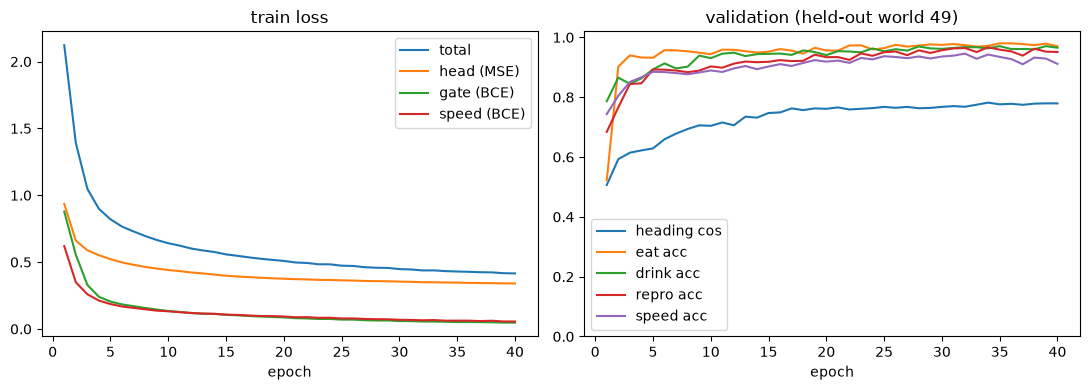

{'heading_cos': 0.779, 'eat_acc': 0.97, 'drink_acc': 0.965, 'repro_acc': 0.951, 'speed_acc': 0.911}


In [7]:
ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [h['tr_loss'] for h in history], label='total')
ax[0].plot(ep, [h['tr_head'] for h in history], label='head (MSE)')
ax[0].plot(ep, [h['tr_gate'] for h in history], label='gate (BCE)')
ax[0].plot(ep, [h['tr_speed'] for h in history], label='speed (BCE)')
ax[0].set_title('train loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, [h['heading_cos'] for h in history], label='heading cos')
ax[1].plot(ep, [h['eat_acc'] for h in history], label='eat acc')
ax[1].plot(ep, [h['drink_acc'] for h in history], label='drink acc')
ax[1].plot(ep, [h['repro_acc'] for h in history], label='repro acc')
ax[1].plot(ep, [h['speed_acc'] for h in history], label='speed acc')
ax[1].set_title(f'validation (held-out world {VAL_WORLD})')
ax[1].set_xlabel('epoch'); ax[1].set_ylim(0, 1.02); ax[1].legend()
plt.tight_layout(); plt.show()

final = history[-1]
print({k: round(final[k], 3) for k in ('heading_cos','eat_acc','drink_acc','repro_acc','speed_acc')})

## Save the model

In [8]:
path = IL.save_model(SID, model, meta={'epochs': len(history),
                                          'val_world': VAL_WORLD,
                                          'final': history[-1]})
print("saved ->", path)

saved -> C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\fox.pt
